- Built on Brian's code

In [1]:
from google.colab import drive
from pathlib import Path
drive.mount('/content/drive')

#test and make sure the drive is properly mounted
!ls "/content/drive/Shareddrives/EMG POSE deep learning/TDS_LSTM/" # this should list all files in the shared drive

Mounted at /content/drive
checkpoints		 meta_subset.csv      __pycache__
data			 model_outscale.py    TDS_LSTM.ipynb
Generalization.ipynb	 model.py	      train.py
load_data.py		 model_simplerCNN.py  welford.py
lr_search_colab.ipynb	 model_tuneCNN.py
meta_subset_12users.csv  outputs


# EMG-to-Pose LSTM Training

This notebook trains an LSTM model to predict hand joint angles from EMG signals.

**Steps:**
1. Setup: clone repo, install deps, download data
2. Configure training parameters
3. Load data, build model, train
4. Evaluate and visualize results

In [2]:
import os
import pandas as pd

## 1. Setup

In [3]:
# Install dependencies
# !pip install -q h5py scipy pandas matplotlib torch

import os

# Clone the repo (skip if already cloned or running locally)
REPO_DIR = "/content/drive/Shareddrives/EMG POSE deep learning/TDS_LSTM/"

os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")

Working directory: /content/drive/Shareddrives/EMG POSE deep learning/TDS_LSTM


In [4]:
# Download mini dataset (~600 MiB)
DATA_DIR = "/content/drive/Shareddrives/EMG POSE deep learning/data/data_subset"
assert os.path.exists(DATA_DIR), "Data is not found!."

n_files = len([f for f in os.listdir(DATA_DIR) if f.endswith('.hdf5')])
print(f"HDF5 files: {n_files}")

HDF5 files: 1888


In [5]:
# Get all .h5 or .hdf5 files
h5_files = [os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR)
            if f.endswith(('.h5', '.hdf5'))]

filenames = [os.path.basename(p).replace('.hdf5', '') for p in h5_files]

# Load metadata
meta = pd.read_csv(os.path.join(DATA_DIR, "metadata.csv"))
meta['filename_key'] = meta['filename'].apply(lambda x: x if x.endswith('.hdf5') else f"{x}.hdf5")


In [6]:
meta_subset = meta[meta['filename'].isin(filenames)].copy()

# train = meta_subset[meta_subset['split'] == 'train'].sample(n=5, random_state=42)
# test = meta_subset[meta_subset['split'] == 'test'].sample(n=1, random_state=42)
# val = meta_subset[meta_subset['split'] == 'val'].sample(n=1, random_state=42)

# meta_subset = pd.concat([train, test, val], ignore_index=True)
# meta_subset.to_csv(os.path.join(REPO_DIR, "meta_subset.csv"), index=False)

In [7]:
# train = meta_subset[meta_subset['split'] == 'train'].sample(n=678, random_state=42)
# test = meta_subset[meta_subset['split'] == 'test'].sample(n=244, random_state=42)
# val = meta_subset[meta_subset['split'] == 'val'].sample(n=77, random_state=42)

# meta_subset = pd.concat([train, test, val], ignore_index=True)
meta_subset.to_csv(os.path.join(REPO_DIR, "meta_subset.csv"), index=False)

## 2. Import from repo modules

In [8]:
import torch
from pathlib import Path

# Import from the repo's .py files
from load_data import get_dataloaders, BATCH_SIZE
from model import TDS_LSTM
from train import (
    train_one_epoch, evaluate,
    save_history, save_model, plot_losses,
)
from welford import apply_welford_to_loaders

print("All modules imported successfully.")

All modules imported successfully.


## 3. Configuration

In [15]:
# G4 GPU configs
CONFIG = {
    # Data
    "data_dir": DATA_DIR,
    "test_mode": False,                     # True = synthetic data (no download)
    "use_test": True,
    "meta_dir": os.path.join(REPO_DIR, "meta_subset.csv"),

    # Model
    "hidden_size": 256,
    "num_layers": 1,
    "dropout": 0.2,        # optional, default is 0.1
    "feature_channels": 256,  # optional, default is 256

    # Training
    "epochs": 50,
    "lr": 1e-4,
    "batch_size": 512,
    "patience": 50,

    # Output
    "output_dir": os.path.join(REPO_DIR, "outputs"),
}

print("Configuration:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

Configuration:
  data_dir: /content/drive/Shareddrives/EMG POSE deep learning/data/data_subset
  test_mode: False
  use_test: True
  meta_dir: /content/drive/Shareddrives/EMG POSE deep learning/TDS_LSTM/meta_subset.csv
  hidden_size: 256
  num_layers: 1
  dropout: 0.2
  feature_channels: 256
  epochs: 50
  lr: 0.0001
  batch_size: 512
  patience: 50
  output_dir: /content/drive/Shareddrives/EMG POSE deep learning/TDS_LSTM/outputs


## 4. Load Data & Build Model

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

# --- Data ---
loaders = get_dataloaders(
    data_dir=CONFIG["data_dir"],
    metadata=CONFIG["meta_dir"],
    test_mode=CONFIG["test_mode"],
    batch_size=CONFIG["batch_size"],
    use_test=CONFIG["use_test"],
    zscore=False
)

print(f"\n{'Split':<8} {'Batches':>8} {'Samples':>10}")
for name, loader in loaders.items():
    print(f"{name:<8} {len(loader):>8} {len(loader.dataset):>10}")

# --- Inspect a batch ---
batch = next(iter(loaders["train"]))
print(f"\nBatch shapes:")
for key, val in batch.items():
    if isinstance(val, torch.Tensor):
        print(f"  {key:<20} {str(val.shape):<25} dtype={val.dtype}")

apply_welford_to_loaders(loaders)

Using device: cuda

=== Loading data from /content/drive/Shareddrives/EMG POSE deep learning/data/data_subset ===
    Metadata: /content/drive/Shareddrives/EMG POSE deep learning/TDS_LSTM/meta_subset.csv


Using splits: train=953, val=308, test=627

Split     Batches    Samples
train           7       4054
val             3       1446
test            9       4284

Batch shapes:
  emg                  torch.Size([512, 16, 11790]) dtype=torch.float32
  joint_angles         torch.Size([512, 20, 11790]) dtype=torch.float32
  no_ik_failure        torch.Size([512, 11790])  dtype=torch.bool
  window_start_idx     torch.Size([512])         dtype=torch.int64
  window_end_idx       torch.Size([512])         dtype=torch.int64
Applied Welford normalization to 1888 session datasets


In [ ]:
batch = next(iter(loaders["train"]))
emg = batch["emg"]  # (B, 16, T)
print(f"EMG mean: {emg.mean():.4f}  (should be ~0)")
print(f"EMG std:  {emg.std():.4f}   (should be ~1)")

EMG mean: 0.0000  (should be ~0)
EMG std:  1.0000   (should be ~1)


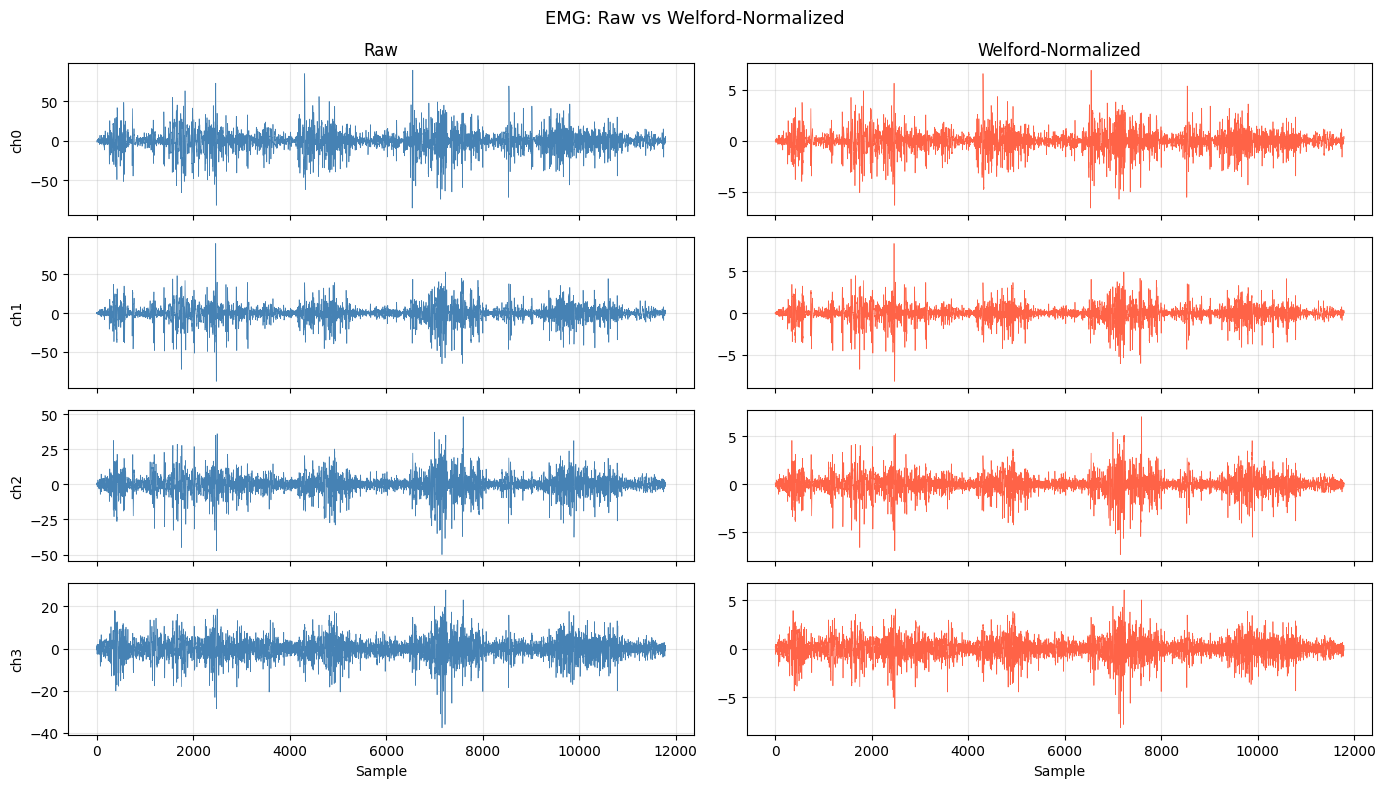

Raw        — mean: 0.0002  std: 19.6392
Normalized — mean: -0.0000  std: 1.0000


In [ ]:
import matplotlib.pyplot as plt
from welford import WELFORD_NORMALIZER, WelfordNormalizeTensor
from data.session import Emg2PoseSessionData

plot_dataset = loaders["train"].dataset.datasets[0]
session = Emg2PoseSessionData(plot_dataset.hdf5_path)
raw_emg = torch.tensor(session.timeseries["emg"][:11790], dtype=torch.float32)  # (T, 16)
session._file.close()

normalized_emg = WELFORD_NORMALIZER(raw_emg)  # (T, 16)

# raw_emg is (T, 16), transpose to (16, T) for plotting per channel
raw_emg = raw_emg.T
normalized_emg = normalized_emg.T

channels_to_plot = [0, 1, 2, 3]
time_axis = range(raw_emg.shape[1])

fig, axes = plt.subplots(len(channels_to_plot), 2, figsize=(14, 8), sharex=True)
fig.suptitle("EMG: Raw vs Welford-Normalized", fontsize=13)

for row, ch in enumerate(channels_to_plot):
    # Raw
    axes[row, 0].plot(time_axis, raw_emg[ch].numpy(), color="steelblue", linewidth=0.5)
    axes[row, 0].set_ylabel(f"ch{ch}")
    axes[row, 0].grid(True, alpha=0.3)
    if row == 0:
        axes[row, 0].set_title("Raw")

    # Normalized
    axes[row, 1].plot(time_axis, normalized_emg[ch].numpy(), color="tomato", linewidth=0.5)
    axes[row, 1].grid(True, alpha=0.3)
    if row == 0:
        axes[row, 1].set_title("Welford-Normalized")

axes[-1, 0].set_xlabel("Sample")
axes[-1, 1].set_xlabel("Sample")
fig.tight_layout()
plt.show()

# Stats confirmation
print(f"Raw        — mean: {raw_emg.mean():.4f}  std: {raw_emg.std():.4f}")
print(f"Normalized — mean: {normalized_emg.mean():.4f}  std: {normalized_emg.std():.4f}")


In [ ]:
from model import TDS_LSTM

# --- Model ---
model = TDS_LSTM(
    hidden_size=CONFIG["hidden_size"],
    num_layers=CONFIG["num_layers"],
    dropout=CONFIG["dropout"],
    feature_channels=CONFIG["feature_channels"],
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model: TDS_LSTM ({n_params:,} parameters)")
print(f"  hidden_size={CONFIG['hidden_size']}, num_layers={CONFIG['num_layers']}")

# --- Optimizer ---
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])

# Scheduler - halves the learning rate whenever val loss stops improving for 10 epochs, letting the model fine-tune after initial convergence.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

# --- Output dir ---
output_dir = Path(CONFIG["output_dir"])
output_dir.mkdir(parents=True, exist_ok=True)


Model: TDS_LSTM (2,558,292 parameters)
  hidden_size=256, num_layers=1


In [11]:
from model_simplerCNN import TDS_LSTM_simplerCNN

# --- Model ---
model = TDS_LSTM_simplerCNN(
    hidden_size=CONFIG["hidden_size"],
    num_layers=CONFIG["num_layers"],
    dropout=CONFIG["dropout"],
    feature_channels=CONFIG["feature_channels"],
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model: TDS_LSTM ({n_params:,} parameters)")
print(f"  hidden_size={CONFIG['hidden_size']}, num_layers={CONFIG['num_layers']}")

# --- Optimizer ---
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])

# Scheduler - halves the learning rate whenever val loss stops improving for 10 epochs, letting the model fine-tune after initial convergence.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

# --- Output dir ---
output_dir = Path(CONFIG["output_dir"])
output_dir.mkdir(parents=True, exist_ok=True)


Model: TDS_LSTM (1,114,964 parameters)
  hidden_size=256, num_layers=1


## 5. Train

In [ ]:
import time

best_loss = float("inf")
epochs_without_improvement = 0
use_test = CONFIG["use_test"] and "test" in loaders
patience = CONFIG["patience"]
max_epochs = CONFIG["epochs"]

history = {"train_loss": [], "val_loss": []}
if use_test:
    history["test_loss"] = []

print(f"Training for up to {max_epochs} epochs (patience={patience})")
print(f"  Checkpoint metric: val_loss")

for epoch in range(1, max_epochs + 1):
    start_time = time.perf_counter()

    train_loss = train_one_epoch(model, loaders["train"], optimizer, device)
    val_loss = evaluate(model, loaders["val"], device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    # Scheduler steps on val loss
    scheduler.step(val_loss)

    # Always checkpoint on val loss
    improved = ""
    if val_loss < best_loss:
        best_loss = val_loss
        epochs_without_improvement = 0
        save_model(model, optimizer, epoch, best_loss,
                   save_path=output_dir / "best_model.pt")
        improved = " *"
    else:
        epochs_without_improvement += 1

    if use_test:
        test_mae = evaluate(model, loaders["test"], device)
        history["test_loss"].append(test_mae)

    log = f"Epoch {epoch:3d}/{max_epochs}  train_loss={train_loss:.4f}"
    end_time = time.perf_counter()

    elapsed_time = end_time - start_time
    print(f"Elapsed time: {elapsed_time} seconds")

    if use_test:
        log += f"  test_loss={test_mae:.4f}"
    log += f"  val_loss={val_loss:.4f}{improved}"
    current_lr = optimizer.param_groups[0]["lr"]
    log += f"  lr={current_lr:.2e}"
    print(log)

    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        break

# Save history
save_history(history, save_path=output_dir / "loss_history.json")

Training for up to 50 epochs (patience=50)
  Checkpoint metric: val_loss
Saved model checkpoint to /content/drive/Shareddrives/EMG POSE deep learning/TDS_LSTM/outputs/best_model.pt (epoch 1)
Elapsed time: 7.627007475000028 seconds
Epoch   1/50  train_loss=0.3964  test_loss=0.4021  val_loss=0.3467 *  lr=1.00e-02
Saved model checkpoint to /content/drive/Shareddrives/EMG POSE deep learning/TDS_LSTM/outputs/best_model.pt (epoch 2)
Elapsed time: 7.742117847000372 seconds
Epoch   2/50  train_loss=0.3643  test_loss=0.3733  val_loss=0.3223 *  lr=1.00e-02
Saved model checkpoint to /content/drive/Shareddrives/EMG POSE deep learning/TDS_LSTM/outputs/best_model.pt (epoch 3)
Elapsed time: 7.627315675000318 seconds
Epoch   3/50  train_loss=0.3387  test_loss=0.3522  val_loss=0.3079 *  lr=1.00e-02
Saved model checkpoint to /content/drive/Shareddrives/EMG POSE deep learning/TDS_LSTM/outputs/best_model.pt (epoch 4)
Elapsed time: 7.628903104000528 seconds
Epoch   4/50  train_loss=0.3212  test_loss=0.3383

KeyboardInterrupt: 

### 1 Conv1d version

reduce conv1d layer to 1, stride = 5

In [12]:
import sys
sys.path.insert(0, "/content/drive/Shareddrives/EMG POSE deep learning/TDS_LSTM/")
from model_simplerCNN import TDS_LSTM_simplerCNN


In [13]:
# --- Model ---
model = TDS_LSTM_simplerCNN(
    hidden_size=CONFIG["hidden_size"],
    num_layers=CONFIG["num_layers"],
    dropout=CONFIG["dropout"],
    feature_channels=CONFIG["feature_channels"],
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model: TDS_LSTM ({n_params:,} parameters)")
print(f"  hidden_size={CONFIG['hidden_size']}, num_layers={CONFIG['num_layers']}")

# --- Optimizer ---
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])

# Scheduler - halves the learning rate whenever val loss stops improving for 10 epochs, letting the model fine-tune after initial convergence.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

# --- Output dir ---
output_dir = Path(CONFIG["output_dir"])
output_dir.mkdir(parents=True, exist_ok=True)



Model: TDS_LSTM (1,114,964 parameters)
  hidden_size=256, num_layers=1


In [ ]:
import time

best_loss = float("inf")
epochs_without_improvement = 0
use_test = CONFIG["use_test"] and "test" in loaders
patience = CONFIG["patience"]
max_epochs = CONFIG["epochs"]

history = {"train_loss": [], "val_loss": []}
if use_test:
    history["test_loss"] = []

print(f"Training for up to {max_epochs} epochs (patience={patience})")
print(f"  Checkpoint metric: val_loss")

for epoch in range(1, max_epochs + 1):
    start_time = time.perf_counter()

    train_loss = train_one_epoch(model, loaders["train"], optimizer, device)
    val_loss = evaluate(model, loaders["val"], device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    # Scheduler steps on val loss
    scheduler.step(val_loss)

    # Always checkpoint on val loss
    improved = ""
    if val_loss < best_loss:
        best_loss = val_loss
        epochs_without_improvement = 0
        save_model(model, optimizer, epoch, best_loss,
                   save_path=output_dir / "best_model_simplerCNN.pt")
        improved = " *"
    else:
        epochs_without_improvement += 1

    if use_test:
        test_mae = evaluate(model, loaders["test"], device)
        history["test_loss"].append(test_mae)

    log = f"Epoch {epoch:3d}/{max_epochs}  train_loss={train_loss:.4f}"
    end_time = time.perf_counter()

    elapsed_time = end_time - start_time
    print(f"Elapsed time: {elapsed_time} seconds")

    if use_test:
        log += f"  test_loss={test_mae:.4f}"
    log += f"  val_loss={val_loss:.4f}{improved}"
    current_lr = optimizer.param_groups[0]["lr"]
    log += f"  lr={current_lr:.2e}"
    print(log)

    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        break

# Save history
save_history(history, save_path=output_dir / "loss_history_simplerCNN.json")

Training for up to 50 epochs (patience=50)
  Checkpoint metric: val_loss
Saved model checkpoint to /content/drive/Shareddrives/EMG POSE deep learning/TDS_LSTM/outputs/best_model_simplerCNN.pt (epoch 1)
Elapsed time: 14.092606345000604 seconds
Epoch   1/50  train_loss=0.2985  test_loss=0.3117  val_loss=0.3011 *  lr=1.95e-05


### Normalized version

model_outscale/TDS_LSTM3: Removed 0.01 scaling output part as normalization already scaled data.

In [ ]:
import sys
sys.path.insert(0, "/content/drive/Shareddrives/EMG POSE deep learning/TDS_LSTM/")
from model_outscale import TDS_LSTM3


In [ ]:
# --- Model ---
model = TDS_LSTM3(
    hidden_size=CONFIG["hidden_size"],
    num_layers=CONFIG["num_layers"],
    dropout=CONFIG["dropout"],
    feature_channels=CONFIG["feature_channels"],
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model: TDS_LSTM ({n_params:,} parameters)")
print(f"  hidden_size={CONFIG['hidden_size']}, num_layers={CONFIG['num_layers']}")

# --- Optimizer ---
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])

# Scheduler - halves the learning rate whenever val loss stops improving for 10 epochs, letting the model fine-tune after initial convergence.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

# --- Output dir ---
output_dir = Path(CONFIG["output_dir"])
output_dir.mkdir(parents=True, exist_ok=True)



Model: TDS_LSTM (2,558,292 parameters)
  hidden_size=256, num_layers=1


In [ ]:

best_loss = float("inf")
epochs_without_improvement = 0
use_test = CONFIG["use_test"] and "test" in loaders
patience = CONFIG["patience"]
max_epochs = CONFIG["epochs"]

history = {"train_loss": [], "val_loss": []}
if use_test:
    history["test_loss"] = []

print(f"Training for up to {max_epochs} epochs (patience={patience})")
print(f"  Checkpoint metric: val_loss")

for epoch in range(1, max_epochs + 1):
    start_time = time.perf_counter()

    train_loss = train_one_epoch(model, loaders["train"], optimizer, device)
    val_loss = evaluate(model, loaders["val"], device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    # Scheduler steps on val loss
    scheduler.step(val_loss)

    # Always checkpoint on val loss
    improved = ""
    if val_loss < best_loss:
        best_loss = val_loss
        epochs_without_improvement = 0
        save_model(model, optimizer, epoch, best_loss,
                   save_path=output_dir / "best_model.pt")
        improved = " *"
    else:
        epochs_without_improvement += 1

    if use_test:
        test_mae = evaluate(model, loaders["test"], device)
        history["test_loss"].append(test_mae)

    log = f"Epoch {epoch:3d}/{max_epochs}  train_loss={train_loss:.4f}"
    end_time = time.perf_counter()

    elapsed_time = end_time - start_time
    print(f"Elapsed time: {elapsed_time} seconds")

    if use_test:
        log += f"  test_loss={test_mae:.4f}"
    log += f"  val_loss={val_loss:.4f}{improved}"
    current_lr = optimizer.param_groups[0]["lr"]
    log += f"  lr={current_lr:.2e}"
    print(log)

    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        break

# Save history
save_history(history, save_path=output_dir / "loss_history.json")

Training for up to 50 epochs (patience=50)
  Checkpoint metric: val_loss
Saved model checkpoint to /content/drive/Shareddrives/EMG POSE deep learning/TDS_LSTM/outputs/best_model.pt (epoch 1)
Elapsed time: 7.920599461000165 seconds
Epoch   1/50  train_loss=0.4574  test_loss=0.3670  val_loss=0.3506 *  lr=1.00e-02
Saved model checkpoint to /content/drive/Shareddrives/EMG POSE deep learning/TDS_LSTM/outputs/best_model.pt (epoch 2)
Elapsed time: 7.864211658000386 seconds
Epoch   2/50  train_loss=0.3263  test_loss=0.3281  val_loss=0.3103 *  lr=1.00e-02
Saved model checkpoint to /content/drive/Shareddrives/EMG POSE deep learning/TDS_LSTM/outputs/best_model.pt (epoch 3)
Elapsed time: 8.018302462000065 seconds
Epoch   3/50  train_loss=0.3077  test_loss=0.3230  val_loss=0.3059 *  lr=1.00e-02
Elapsed time: 7.79464997299965 seconds
Epoch   4/50  train_loss=0.3058  test_loss=0.3212  val_loss=0.3096  lr=1.00e-02
Saved model checkpoint to /content/drive/Shareddrives/EMG POSE deep learning/TDS_LSTM/ou

## 6. Visualize & Evaluate

In [ ]:
# Plot training curves (displays inline in Colab)
plot_losses(history, save_path=output_dir / "training_curves.png")

Saved training curves to /content/drive/Shareddrives/EMG POSE deep learning/TDS_LSTM/outputs/training_curves.png


In [ ]:
# Load best model and evaluate on test set
metric_name = "test_loss" if use_test else "val_loss"
print(f"Best {metric_name}: {best_loss:.4f}")

best_ckpt = output_dir / "best_model.pt"
if best_ckpt.exists():
    checkpoint = torch.load(best_ckpt, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"Loaded best model from epoch {checkpoint['epoch']}")

test_loss = evaluate(model, loaders["val"], device)
print(f"Validation loss (MAE): {test_loss:.4f}")

Best test_loss: 0.3008
Loaded best model from epoch 5
Validation loss (MAE): 0.3008


In [ ]:
# Download outputs from Colab (uncomment to use)

# from google.colab import files
# files.download(str(output_dir / "best_model.pt"))
# files.download(str(output_dir / "loss_history.json"))
# files.download(str(output_dir / "training_curves.png"))

### Tune CNN

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 11.7 MB/s eta 0:00:00


In [ ]:
import importlib
import model_tuneCNN
importlib.reload(model_tuneCNN)
from model_tuneCNN import TDS_LSTM2

In [ ]:
# ── 1. quick_train ──────────────────────────────────────────────────
def quick_train(model, train_loader, val_loader, epochs, device, optimizer):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )
    best_val = float("inf")
    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, device)
        val_loss = evaluate(model, val_loader, device)
        scheduler.step(val_loss)
        if val_loss < best_val:
            best_val = val_loss
    return best_val


# ── 2. parameter maps ───────────────────────────────────────────────
stride_map = {
    "5_2_4": (5, 2, 4),
    "4_2_5": (4, 2, 5),
    "5_4_2": (5, 4, 2),
}
tds_map = {
    "9_9_5_5":  (9, 9, 5, 5),
    "7_7_5_5":  (7, 7, 5, 5),
    "9_9_7_7":  (9, 9, 7, 7),
    "11_9_5_5": (11, 9, 5, 5),
}


# ── 3. objective ────────────────────────────────────────────────────
def objective(trial):
    # LSTM params
    hidden_size = trial.suggest_categorical("hidden_size", [256, 384, 512])
    num_layers  = trial.suggest_categorical("num_layers", [1, 2, 3])
    dropout     = trial.suggest_float("dropout", 0.0, 0.4, step=0.1)
    lr          = trial.suggest_categorical("lr", [1e-4, 1e-3, 1e-2])

    # CNN params
    k1         = trial.suggest_categorical("k1", [7, 11, 15, 21])
    k2         = trial.suggest_categorical("k2", [3, 5, 7, 11])
    k3         = trial.suggest_categorical("k3", [11, 17, 23, 33])
    s1, s2, s3 = stride_map[trial.suggest_categorical("strides", list(stride_map.keys()))]
    tds_kw     = tds_map[trial.suggest_categorical("tds_kw", list(tds_map.keys()))]

    model = TDS_LSTM2(
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        conv_kernels=(k1, k2, k3),
        conv_strides=(s1, s2, s3),
        tds_kernel_widths=tds_kw,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    val_loss = quick_train(model, loaders["train"], loaders["val"],
                           epochs=10, device=device, optimizer=optimizer)
    return val_loss


# ── 4. run the study ────────────────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.INFO)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)  # increased since search space is larger

print("\nBest params:", study.best_params)
print("Best val loss:", study.best_value)

[I 2026-03-14 00:46:17,137] A new study created in memory with name: no-name-853571e8-bb87-4c09-a8ba-0bbaed055350
[I 2026-03-14 00:47:21,068] Trial 0 finished with value: 0.33938273787498474 and parameters: {'hidden_size': 256, 'num_layers': 2, 'dropout': 0.0, 'lr': 0.001, 'k1': 21, 'k2': 5, 'k3': 23, 'strides': '4_2_5', 'tds_kw': '9_9_5_5'}. Best is trial 0 with value: 0.33938273787498474.
[I 2026-03-14 00:48:24,921] Trial 1 finished with value: 0.3758437931537628 and parameters: {'hidden_size': 256, 'num_layers': 3, 'dropout': 0.0, 'lr': 0.0001, 'k1': 11, 'k2': 7, 'k3': 33, 'strides': '5_2_4', 'tds_kw': '7_7_5_5'}. Best is trial 0 with value: 0.33938273787498474.
[I 2026-03-14 00:49:24,903] Trial 2 finished with value: 0.37414198120435077 and parameters: {'hidden_size': 256, 'num_layers': 2, 'dropout': 0.1, 'lr': 0.0001, 'k1': 7, 'k2': 3, 'k3': 23, 'strides': '5_4_2', 'tds_kw': '7_7_5_5'}. Best is trial 0 with value: 0.33938273787498474.
[I 2026-03-14 00:50:26,637] Trial 3 finished w

KeyboardInterrupt: 